In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
# Load the data from the JSON file
characters = pd.read_json('characters.json')
devil_fruits = pd.read_json('devil_fruits.json')
islands = pd.read_json('islands.json')

In [106]:
# Keep columns of interest
characters = characters[['name', 'affiliation', 'first_appearance_arc', 'race', 'status', 'devil_fruit', 'origin', 'height', 'age', 'haki', 'bounty','relationships','journey']]
devil_fruits = devil_fruits[['name', 'english', 'type','user', 'description']]
islands = islands[['name', 'location', 'notable_members', 'current_ruler', 'notable_locations']]


In [ ]:
#---Data Cleaning---

# --- BOUNTY CLEANING ---
characters['bounty'] = characters['bounty'].astype(str).str.replace(r'\D', '', regex=True)
characters['bounty'] = pd.to_numeric(characters['bounty'], errors='coerce').fillna(0)

# --- CHAPTER CLEANING ---
# Filter for manga-only characters
characters = characters[characters['first_appearance_arc'].str.contains('Chapter', na=False)].copy()

# Fix: Extract the number and convert to integer
characters['chapter_num'] = characters['first_appearance_arc'].str.extract(r'(\d+)').astype(int)

# Set display to avoid scientific notation in the console
pd.options.display.float_format = '{:.0f}'.format

In [125]:
# for each devil fruit user, find their type the chapter of their first appearance
fruits_useful = devil_fruits[['user', 'type']]
for i in range(len(fruits_useful)):
    user = fruits_useful.loc[i, 'user']
    fruit_type = fruits_useful.loc[i, 'type']
    chapter = characters[characters['name'] == user]['chapter_num'].values
    

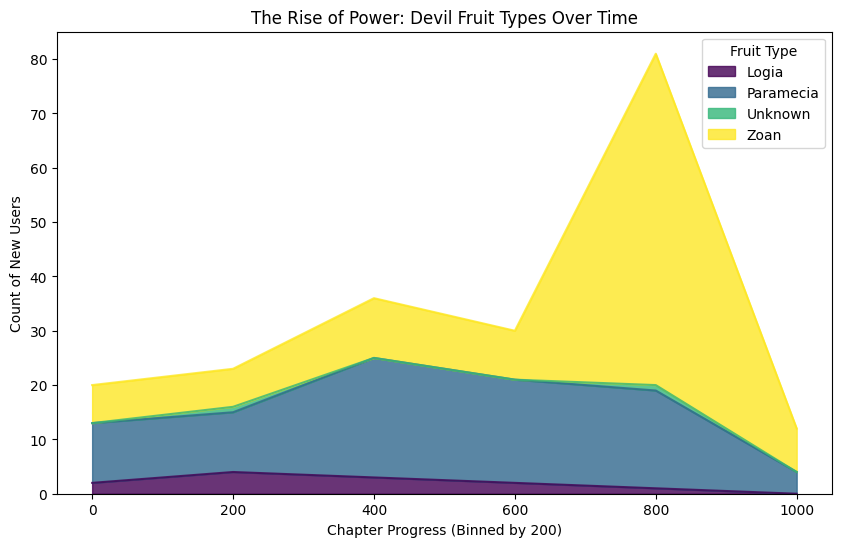

In [127]:
# This does exactly what your 'for' loop intends: 
# For each fruit user, find their type and their appearance chapter.
df_plot = devil_fruits[['user', 'type']].merge(
    characters[['name', 'chapter_num']], 
    left_on='user', 
    right_on='name'
)

# Now we prepare it for the Stacked Area Graph
# 1. Group by chapter intervals
df_plot['chapter_bin'] = (df_plot['chapter_num'] // 200) * 200

# 2. Create the pivot table (Cross-tabulation)
stacked_data = df_plot.groupby(['chapter_bin', 'type']).size().unstack(fill_value=0)

# 3. Plotting
ax = stacked_data.plot.area(figsize=(10, 6), alpha=0.8, colormap='viridis')

plt.title("The Rise of Power: Devil Fruit Types Over Time")
plt.xlabel("Chapter Progress (Binned by 200)")
plt.ylabel("Count of New Users")
plt.legend(title="Fruit Type")
plt.show()

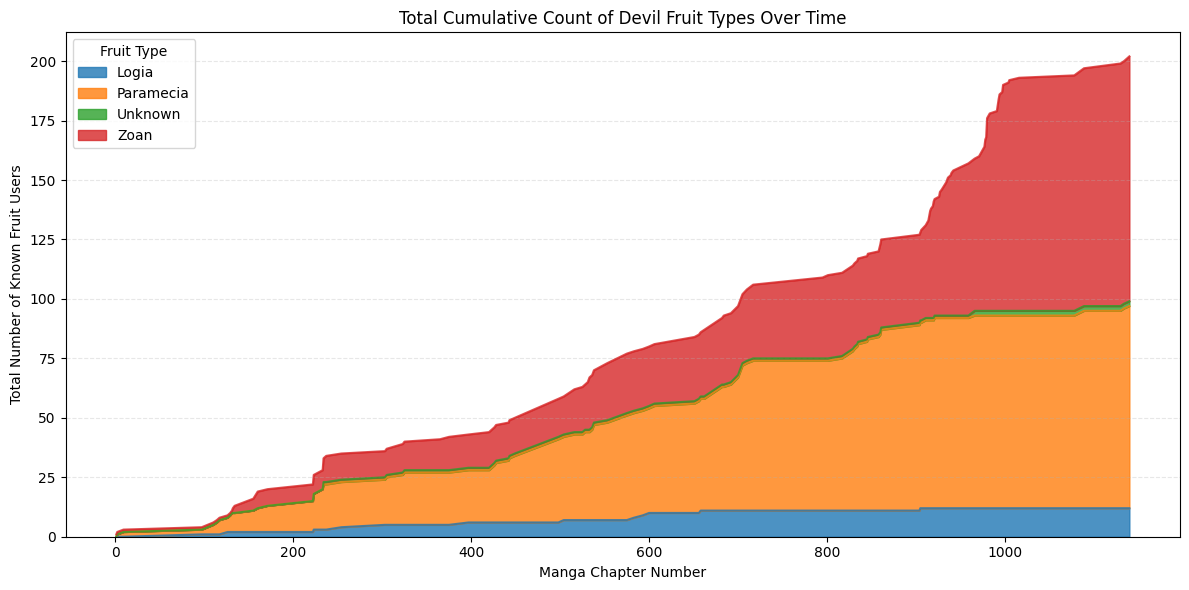

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data (Merging 'tables' like a database)
# We merge characters and devil_fruits to link the appearance chapter to the fruit type
df_cumulative = devil_fruits[['user', 'type']].merge(
    characters[['name', 'chapter_num']], 
    left_on='user', 
    right_on='name'
)

# 2. Sort by chapter to ensure the timeline is correct
df_cumulative = df_cumulative.sort_values('chapter_num')

# 3. Create a pivot table: Rows = Chapters, Columns = Fruit Types, Values = Count
# This creates a 'snapshot' of how many of each type appear in each chapter
counts_per_chapter = df_cumulative.groupby(['chapter_num', 'type']).size().unstack(fill_value=0)

# 4. CALCULATE CUMULATIVE SUM
# This adds the count of the current chapter to the total of all previous chapters
cumulative_data = counts_per_chapter.cumsum()

# 5. Plotting the Stacked Area Graph
ax = cumulative_data.plot.area(figsize=(12, 6), alpha=0.8)

# Requirements: Title, Axis Labels, Legend, and Annotation [cite: 2, 26, 27, 28]
plt.title("Total Cumulative Count of Devil Fruit Types Over Time")
plt.xlabel("Manga Chapter Number")
plt.ylabel("Total Number of Known Fruit Users")
plt.legend(title="Fruit Type", loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()